In [1]:
# !pip install -q keras==3.11.2

In [2]:
import os

os.environ["KERAS_BACKEND"] = "torch"

import keras
from keras import models
from keras import layers
from keras import ops

import torch
import torch.nn as nn
import torchvision
from torchvision import transforms

from torch.utils.data import Dataset, DataLoader

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-notebook")
plt.style.use("petroff10")
plt.set_loglevel("error")

print(f"Keras: {keras.__version__}")
print(f"Numpy: {np.__version__}")

Keras: 3.11.2
Numpy: 2.0.2


In [3]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

In [4]:
device

device(type='cuda')

In [5]:
#How many values are in the input? We use this to help determine the size of subsequent layers
D = 28 * 28  #28 * 28 images
#Hidden layer size
n = 2
#How many channels are in the input?
C = 1
#How many classes are there?
classes = 10

In [6]:
class TransposeLinear(layers.Layer):
    """
    A layer that computes the transpose of another Dense layer's weights.
    This enables weight sharing between an original Dense layer and its transpose.
    """

    def __init__(self, dense_layer, use_bias=True, **kwargs):
        """
        Args:
            dense_layer: The Dense layer whose weights we want to transpose
            use_bias: If True, create a separate bias term for this layer
        """
        super().__init__(**kwargs)
        self.dense_layer = dense_layer
        self.use_bias = use_bias
        self.bias = None

    def build(self, input_shape):
        super().build(input_shape)

        # Ensure the dense layer is built so we can access its kernel
        if not self.dense_layer.built:
            # Build the dense layer with the transposed input shape
            self.dense_layer.build((None, input_shape[-1]))

        if self.use_bias:
            # Create bias with shape matching the transposed output
            # Output shape will be the input dimension of the original dense layer
            output_dim = self.dense_layer.kernel.shape[0]
            self.bias = self.add_weight(
                name='bias',
                shape=(output_dim,),
                initializer='zeros',
                trainable=True
            )

    def call(self, inputs):
        inputs = inputs.to(device)
        # Transpose the shared weights and apply linear transformation
        transposed_weights = ops.transpose(self.dense_layer.kernel)
        output = ops.matmul(inputs, transposed_weights)

        if self.use_bias:
            output = ops.add(output, self.bias)

        return output

    def get_config(self):
        config = super().get_config()
        config.update({
            'use_bias': self.use_bias,
        })
        return config


# Define the shared linear layer (equivalent to nn.Linear)
# Assuming D and n are defined elsewhere (input and latent dimensions)
# D = 784  # For MNIST: 28*28
# n = 50   # Latent dimension

linear_layer = layers.Dense(n, use_bias=False, name='shared_linear')

# PCA Encoder: flatten input and apply linear transformation
pca_encoder = layers.Pipeline([
    layers.Flatten(name='flatten'),
    linear_layer
], name='pca_encoder')

# PCA Decoder: apply transpose linear transformation and reshape back
pca_decoder = layers.Pipeline([
    TransposeLinear(linear_layer, use_bias=False, name='transpose_linear'),
    layers.Reshape(target_shape=(1, 28, 28)),
], name='pca_decoder')

# Complete PCA model: encoder followed by decoder
pca_model = models.Sequential([
    layers.Input(shape=(1, 28, 28)),
    layers.Flatten(),
    pca_encoder,
    pca_decoder
], name='pca_model')


# Custom loss function with orthogonality regularization
class MSEWithOrthoLoss(keras.losses.Loss):
    def __init__(self, regularization_weight=0.1, name='mse_with_ortho_loss'):
        super().__init__(name=name)
        self.regularization_weight = regularization_weight

    def call(self, y_true, y_pred):
        # Get the weights from the shared linear layer
        W = linear_layer.kernel  # Shape: (input_dim, latent_dim)

        # Create identity matrix for regularization target
        I = ops.eye(ops.shape(W)[1])  # Shape: (latent_dim, latent_dim)

        # Compute standard MSE loss
        mse_loss = keras.losses.mean_squared_error(y_true, y_pred)
        normal_loss = ops.mean(mse_loss)

        # Compute orthogonality regularization: ||W^T @ W - I||²
        WtW = ops.matmul(ops.transpose(W), W)
        regularization_loss = self.regularization_weight * ops.mean(
            keras.losses.mean_squared_error(I, WtW)
        )

        return normal_loss + regularization_loss


# Instantiate the custom loss
mse_with_ortho_loss = MSEWithOrthoLoss()

In [7]:
pca_model.summary()

Model: "pca_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pca_encoder (Pipeline)          │ (None, 2)              │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pca_decoder (Pipeline)          │ (None, 1, 28, 28)      │         1,568 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,568 (6.12 KB)

 Trainable params: 1,568 (6.12 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
class AutoEncodeDataset(Dataset):
    """Takes a dataset with (x, y) label pairs and converts it to (x, x) pairs.
    This makes it easy to re-use other code"""

    def __init__(self, dataset):
        self.dataset = dataset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        x, y = self.dataset.__getitem__(idx)
        return x, x  #just throw away the original label.

In [9]:
train_data = AutoEncodeDataset(
    torchvision.datasets.MNIST("./", train=True, transform=transforms.ToTensor(), download=True))
test_data_xy = torchvision.datasets.MNIST("./", train=False, transform=transforms.ToTensor(), download=True)
test_data_xx = AutoEncodeDataset(test_data_xy)

train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
test_loader = DataLoader(test_data_xx, batch_size=128)

100%|██████████| 9.91M/9.91M [00:00<00:00, 16.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 482kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.87MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.16MB/s]


In [10]:
# for d in train_loader:
#     print(d[0].shape)
#     break

In [11]:
# Compile the model
pca_model.compile(
    optimizer='adam',
    loss=mse_with_ortho_loss,
    metrics=['mse']
)

pca_model.fit(train_loader, epochs=10)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - loss: 0.0711 - mse: 0.0703
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - loss: 0.0586 - mse: 0.0586
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - loss: 0.0580 - mse: 0.0580
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - loss: 0.0579 - mse: 0.0579
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - loss: 0.0579 - mse: 0.0579
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - loss: 0.0579 - mse: 0.0579
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - loss: 0.0579 - mse: 0.0579
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - loss: 0.0579 - mse: 0.0579
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - loss: 0.0579 - mse: 0.0579
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - loss: 0.0579 - mse: 0.0579


In [12]:
def encode_batch(encoder, dataset_to_encode):
    """
    encoder: the PyTorch network that takes in a dataset and convers it to a new dimension
    dataset_to_encode: a PyTorch `Dataset` object that we want to convert.

    Returns a tuple (projected, labels) where `projected` is the encoded version of the dataset, and `labels` are the original labels provided by the `dataset_to_encode`
    """
    #Create space to store the results
    projected = []
    labels = []
    with torch.no_grad():  #We don't want to train, so torch.no_grad!
        for x, y in DataLoader(dataset_to_encode, batch_size=128):
            z = encoder(x)  #encode the original data
            projected.append(z.cpu().numpy())  #store the encoded version & label
            labels.append(y.cpu().numpy().ravel())
    #Turn the results into single large numpy arrays
    projected = np.vstack(projected)
    labels = np.hstack(labels)
    #return the results
    return projected, labels


#Now lets project our data
projected, labels = encode_batch(pca_encoder, test_data_xy)

<Axes: >

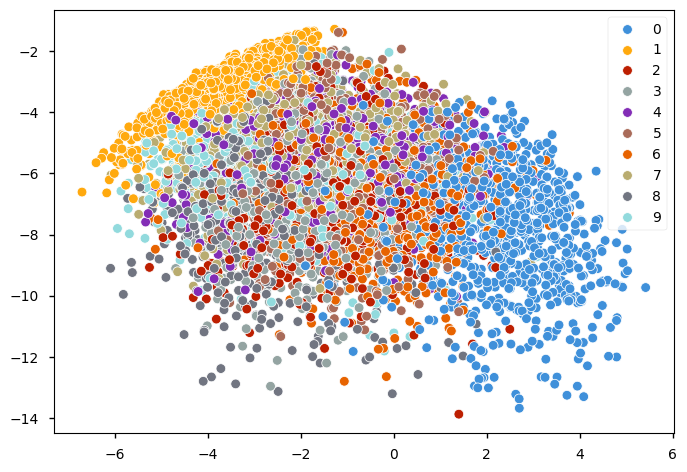

In [13]:
sns.scatterplot(x=projected[:, 0], y=projected[:, 1], hue=[str(l) for l in labels],
                hue_order=[str(i) for i in range(10)], legend="full")

In [14]:
def show_encode_decode(encode_decode, x):
    """
    encode_decode: the PyTorch Module that does the encoding and decoding steps at once
    x: the input to plot as is, and after encoding & decoding it
    """
    with torch.no_grad():
        x_recon = encode_decode(torch.unsqueeze(x, dim=0))
        #Use matplotlib to create a size-by-side plot with the original on the left
        f, axarr = plt.subplots(1, 2)
        axarr[0].imshow(x.cpu().numpy()[0, :])
        axarr[1].imshow(x_recon.detach().cpu().numpy()[0, 0, ...])

In [15]:
test_data_xy[0][0].size()

torch.Size([1, 28, 28])

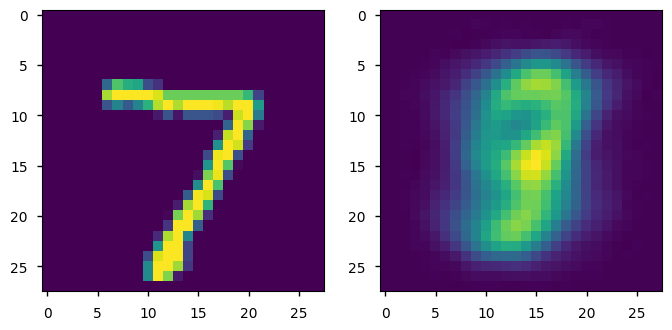

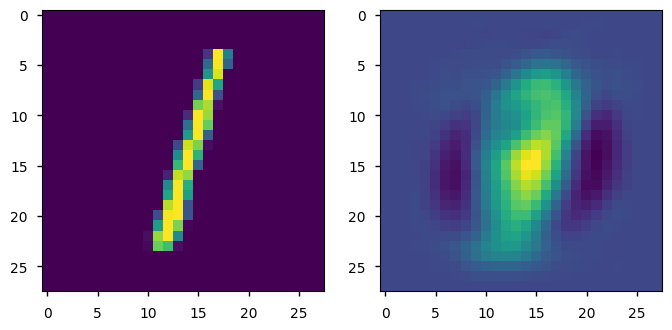

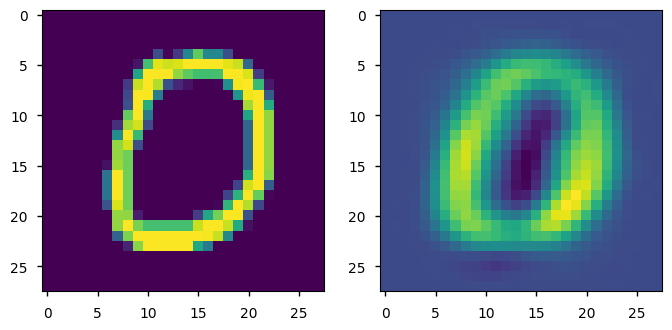

In [16]:
#Showing the input (left) and output (right) for three data points
show_encode_decode(pca_model, test_data_xy[0][0])
show_encode_decode(pca_model, test_data_xy[2][0])
show_encode_decode(pca_model, test_data_xy[10][0])

In [17]:
pca_nonlinear_encoder = layers.Pipeline([
    layers.Flatten(name='flatten'),
    layers.Dense(n, activation="tanh"),
], name='pca_encoder')

pca_nonlinear_decoder = layers.Pipeline([
    layers.Dense(D),
    layers.Reshape(target_shape=(1, 28, 28)),
], name='pca_decoder')

pca_nonlinear = models.Sequential([
    layers.Input(shape=(1, 28, 28)),
    layers.Flatten(),
    pca_nonlinear_encoder,
    pca_nonlinear_decoder
], name='pca_model')

pca_nonlinear.compile(
    optimizer='adam',
    loss="mse",
    metrics=['mse']
)

pca_nonlinear.fit(train_loader, epochs=10)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - loss: 0.0706 - mse: 0.0706
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - loss: 0.0596 - mse: 0.0596
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - loss: 0.0575 - mse: 0.0575
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - loss: 0.0568 - mse: 0.0568
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - loss: 0.0564 - mse: 0.0564
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - loss: 0.0562 - mse: 0.0562
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - loss: 0.0561 - mse: 0.0561
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - loss: 0.0561 - mse: 0.0561
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - loss: 0.0560 - mse: 0.0560
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - loss: 0.0560 - mse: 0.0560


<Axes: >

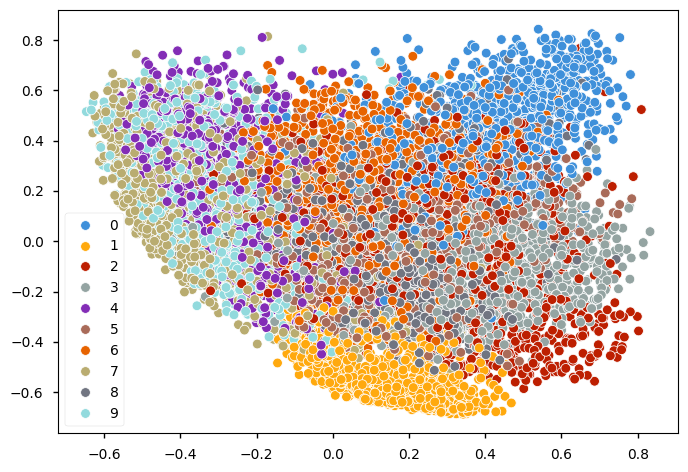

In [18]:
projected, labels = encode_batch(pca_nonlinear_encoder, test_data_xy)
sns.scatterplot(x=projected[:, 0], y=projected[:, 1], hue=[str(l) for l in labels],
                hue_order=[str(i) for i in range(10)], legend="full")

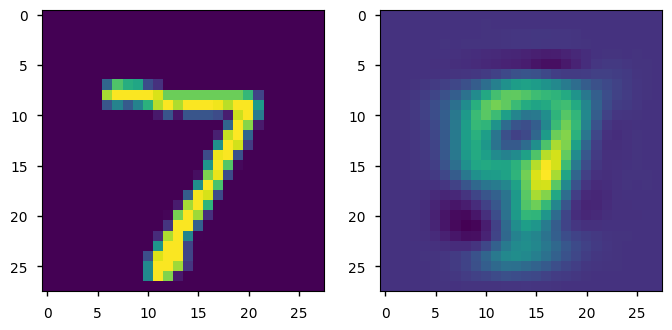

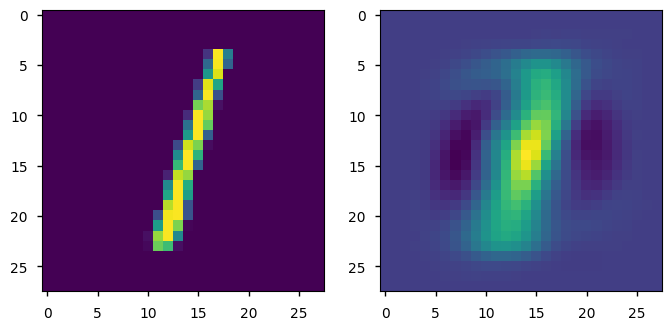

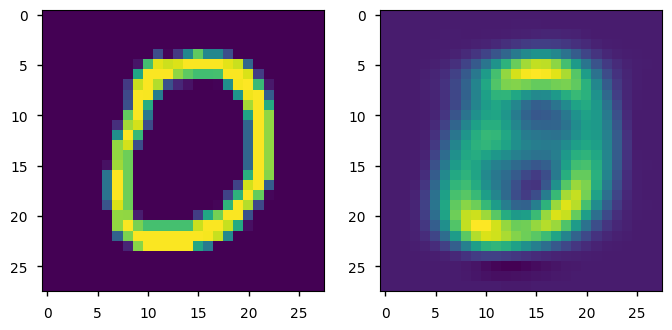

In [19]:
show_encode_decode(pca_nonlinear, test_data_xy[0][0])
show_encode_decode(pca_nonlinear, test_data_xy[2][0])
show_encode_decode(pca_nonlinear, test_data_xy[10][0])

In [20]:
n, D

(2, 784)

In [21]:
def get_layer(out_size, activation="gelu"):
    """
    in_size: how many neurons/features are coming into this layer
    out_size: how many neurons/outputs this hidden layer should produce
    """
    return layers.Pipeline([
        layers.Dense(out_size, use_bias=True),
        layers.LayerNormalization(),
        layers.Activation(activation)
    ])


auto_encoder = layers.Pipeline([
    layers.Flatten(name='flatten'),
    get_layer(D // 2),
    get_layer(D // 3),
    get_layer(D // 4),
    layers.Dense(2)
], name='auto_encoder')

auto_decoder = layers.Pipeline([
    get_layer(D // 4),
    get_layer(D // 3),
    get_layer(D // 2),
    layers.Dense(D, activation="sigmoid"),
    layers.Reshape(target_shape=(1, 28, 28)),
], name='auto_decoder')

auto_encode_decode = models.Sequential([
    layers.Input(shape=(1, 28, 28)),
    auto_encoder,
    auto_decoder
], name='auto_encode_decode')

auto_encode_decode.compile(
    optimizer=keras.optimizers.AdamW(),
    loss=keras.losses.MeanSquaredError(),
    metrics=[keras.losses.MeanSquaredError()]
)

auto_encode_decode.fit(train_loader, epochs=10)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - loss: 0.0574 - mean_squared_error: 0.0574
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - loss: 0.0437 - mean_squared_error: 0.0437
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - loss: 0.0395 - mean_squared_error: 0.0395
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - loss: 0.0382 - mean_squared_error: 0.0382
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - loss: 0.0374 - mean_squared_error: 0.0374
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - loss: 0.0367 - mean_squared_error: 0.0367
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - loss: 0.0364 - mean_squared_error: 0.0364
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - loss: 0.0360 - mean_squared_error: 0.0360
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - loss: 0.0356 - mean_squared_error: 0.0356
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - loss: 0.0355 - mean_squared_error: 0.0355


<Axes: >

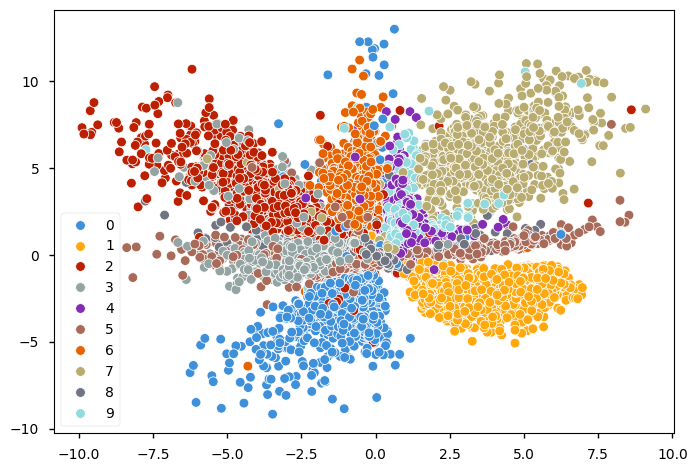

In [22]:
projected, labels = encode_batch(auto_encoder, test_data_xy)
sns.scatterplot(x=projected[:, 0], y=projected[:, 1], hue=[str(l) for l in labels],
                hue_order=[str(i) for i in range(10)], legend="full")

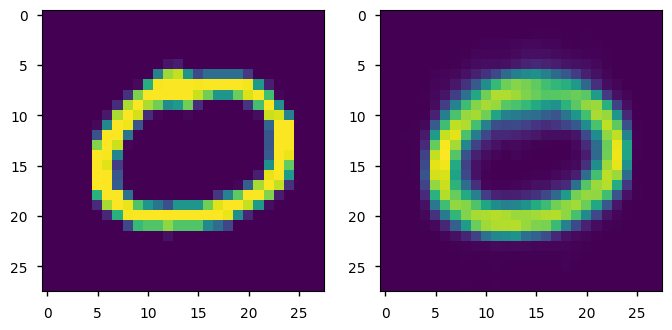

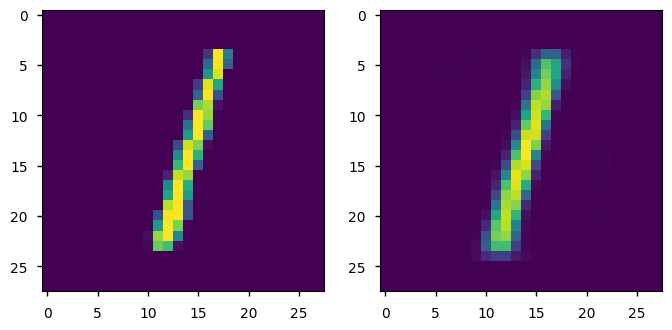

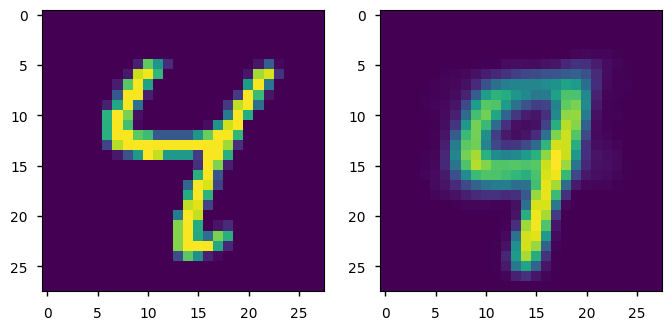

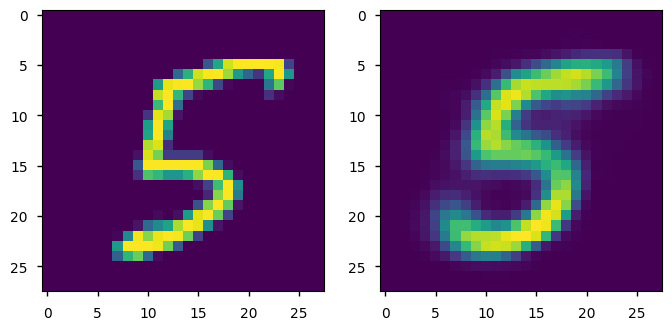

In [23]:
show_encode_decode(auto_encode_decode, test_data_xy[69][0])
show_encode_decode(auto_encode_decode, test_data_xy[2][0])
show_encode_decode(auto_encode_decode, test_data_xy[6][0])
show_encode_decode(auto_encode_decode, test_data_xy[23][0])

In [24]:
auto_encoder_big = layers.Pipeline([
    layers.Flatten(name='flatten'),
    get_layer(D * 2),
    get_layer(D * 2),
    get_layer(D * 2),
    layers.Dense(D * 2)
], name='auto_encoder_big')

auto_decoder_big = layers.Pipeline([
    get_layer(D * 2),
    get_layer(D * 2),
    get_layer(D * 2),
    #get_layer(D),
    keras.layers.Dense(D, activation="sigmoid"),
    layers.Reshape(target_shape=(1, 28, 28)),
], name='auto_decoder_big')

auto_encode_decode_big = models.Sequential([
    layers.Input(shape=(1, 28, 28)),
    auto_encoder_big,
    auto_decoder_big
], name='auto_encode_decode_big')

auto_encode_decode_big.compile(
    optimizer=keras.optimizers.AdamW(),
    loss=keras.losses.MeanSquaredError(reduction="mean"),
    metrics=[keras.losses.MeanSquaredError(reduction="mean")]
)

auto_encode_decode_big.fit(train_loader, epochs=10)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 38ms/step - loss: 0.0518 - mean_squared_error: 0.0518
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 39ms/step - loss: 0.0262 - mean_squared_error: 0.0262
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 39ms/step - loss: 0.0177 - mean_squared_error: 0.0176
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - loss: 0.0126 - mean_squared_error: 0.0126
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 25s 53ms/step - loss: 0.0099 - mean_squared_error: 0.0099
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 38ms/step - loss: 0.0084 - mean_squared_error: 0.0084
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 40ms/step - loss: 0.0074 - mean_squared_error: 0.0074
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - loss: 0.0067 - mean_squared_error: 0.0067
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 39ms/step - loss: 0.0061 - mean_squared_error: 0.0061
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 39ms/step - loss: 0.0057 - mean_squared_error: 0.0057


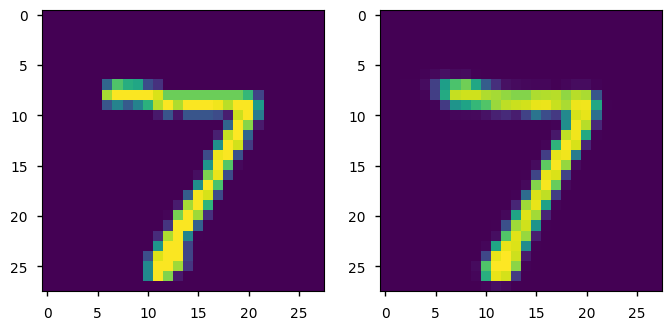

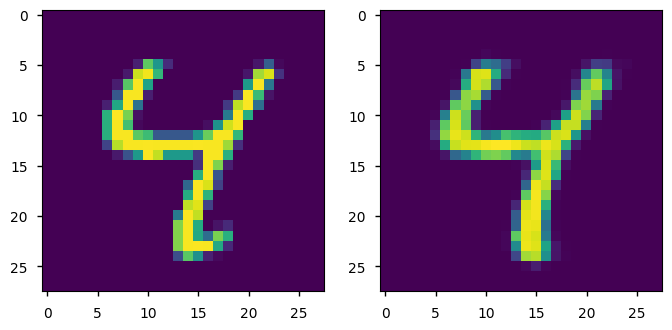

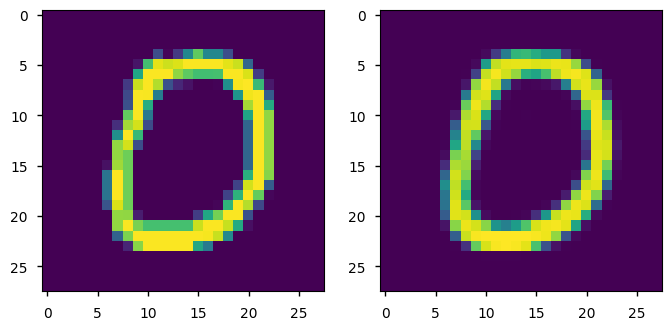

In [25]:
show_encode_decode(auto_encode_decode_big, test_data_xy[0][0])
show_encode_decode(auto_encode_decode_big, test_data_xy[6][0])
show_encode_decode(auto_encode_decode_big, test_data_xy[10][0])

In [26]:
def add_noise(x, device='cpu'):
    """
    We will use this helper function to add noise to some data.
    x: the data we want to add noise to
    device: the CPU or GPU that the input is located on.
    """
    normal = torch.distributions.Normal(0, 0.5)
    return x + normal.sample(sample_shape=torch.Size(x.shape)).to(device)

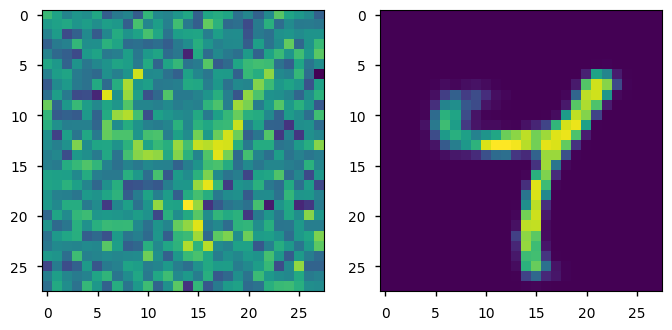

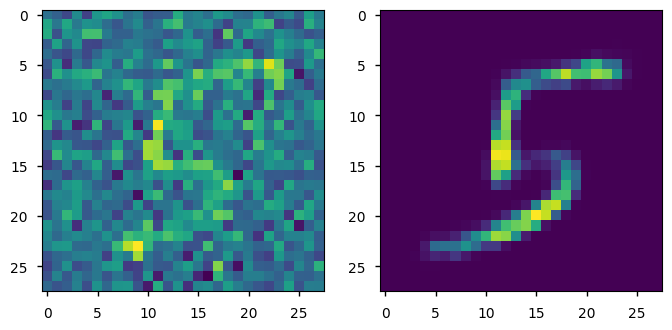

In [27]:
show_encode_decode(auto_encode_decode_big, add_noise(test_data_xy[6][0]))
show_encode_decode(auto_encode_decode_big, add_noise(test_data_xy[23][0]))

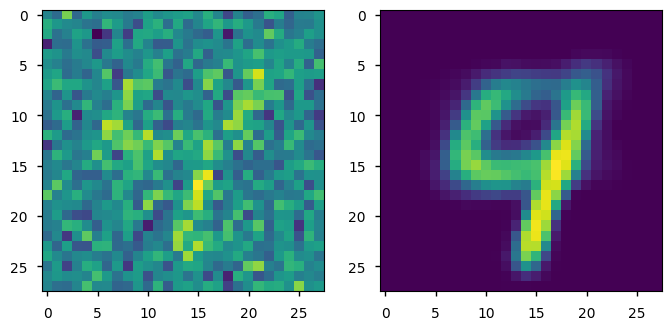

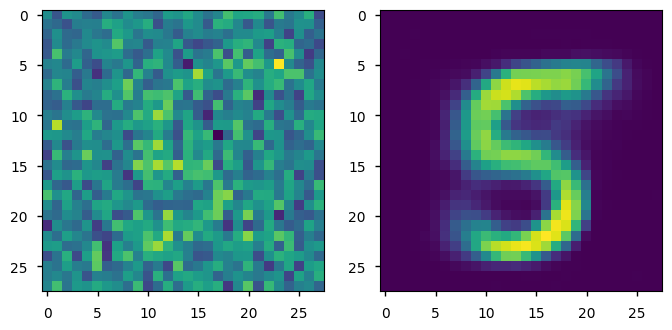

In [28]:
show_encode_decode(auto_encode_decode, add_noise(test_data_xy[6][0]))
show_encode_decode(auto_encode_decode, add_noise(test_data_xy[23][0]))

In [29]:
class AdditiveGaussianNoise(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        # No additional initialization needed

    def call(self, inputs, training=None):
        # Keras automatically passes the training flag to the call method
        if training:
            return self.add_noise(inputs)
        else:
            return inputs

    def add_noise(self, x):
        # You'll need to implement your addNoise function here
        # This is a placeholder - replace with your actual noise implementation
        # Example Gaussian noise implementation:
        noise = keras.random.normal(
            shape=ops.shape(x),
            mean=0.0,
            stddev=1.0,  # Adjust stddev as needed
            dtype=x.dtype
        )
        return x + noise

In [30]:
dnauto_encoder_big = layers.Pipeline([
    layers.Flatten(name='flatten'),
    AdditiveGaussianNoise(),
    get_layer(D * 2),
    get_layer(D * 2),
    get_layer(D * 2),
    layers.Dense(D * 2)
], name='dnauto_encoder_big')

dnauto_decoder_big = layers.Pipeline([
    get_layer(D * 2),
    get_layer(D * 2),
    get_layer(D * 2),
    #get_layer(D),
    keras.layers.Dense(D, activation="sigmoid"),
    layers.Reshape(target_shape=(1, 28, 28)),
], name='dnauto_decoder_big')

dnauto_encode_decode_big = models.Sequential([
    layers.Input(shape=(1, 28, 28)),
    dnauto_encoder_big,
    dnauto_decoder_big
], name='auto_encode_decode_big')

dnauto_encode_decode_big.compile(
    optimizer=keras.optimizers.AdamW(),
    loss=keras.losses.MeanSquaredError(reduction="mean"),
    metrics=[keras.losses.MeanSquaredError(reduction="mean")]
)

dnauto_encode_decode_big.fit(train_loader, epochs=10)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 41ms/step - loss: 0.0684 - mean_squared_error: 0.0684
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 29s 62ms/step - loss: 0.0585 - mean_squared_error: 0.0585
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 24s 51ms/step - loss: 0.0456 - mean_squared_error: 0.0456
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 40ms/step - loss: 0.0389 - mean_squared_error: 0.0389
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 41ms/step - loss: 0.0349 - mean_squared_error: 0.0349
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 39ms/step - loss: 0.0324 - mean_squared_error: 0.0324
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - loss: 0.0306 - mean_squared_error: 0.0306
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 40ms/step - loss: 0.0293 - mean_squared_error: 0.0293
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 41ms/step - loss: 0.0284 - mean_squared_error: 0.0284
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 40ms/step - loss: 0.0274 - mean_squared_error: 0.0274


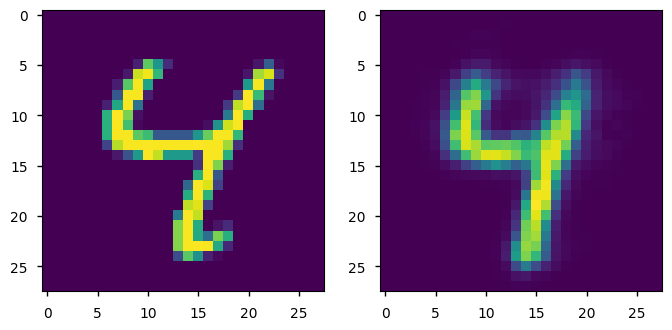

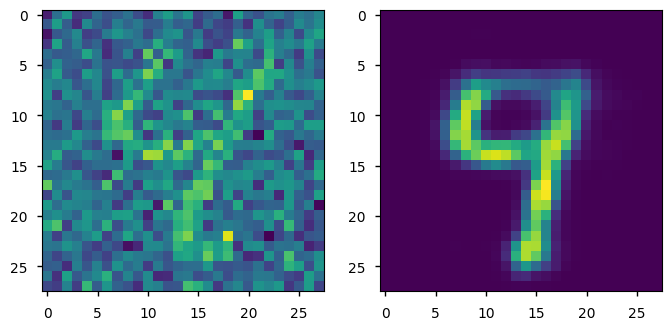

In [31]:
show_encode_decode(dnauto_encode_decode_big, test_data_xy[6][0])
show_encode_decode(dnauto_encode_decode_big, add_noise(test_data_xy[6][0]))

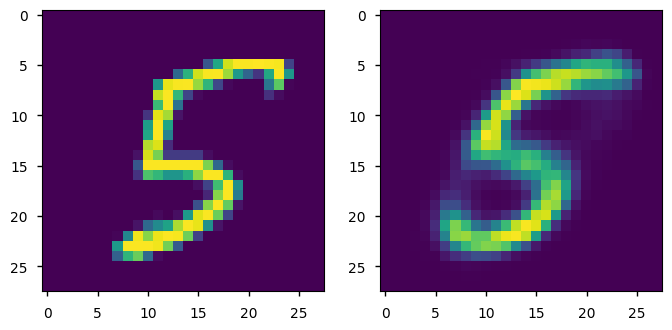

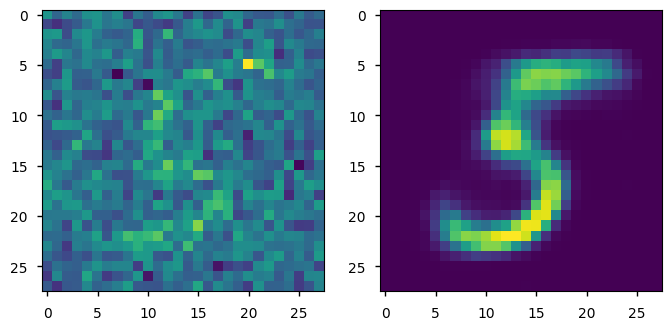

In [32]:
show_encode_decode(dnauto_encode_decode_big, test_data_xy[23][0])
show_encode_decode(dnauto_encode_decode_big, add_noise(test_data_xy[23][0]))

In [33]:
dnauto_encoder_dropout = layers.Pipeline([
    layers.Flatten(name='flatten'),
    layers.Dropout(0.2),
    get_layer(D * 2),
    layers.Dropout(0.5),
    get_layer(D * 2),
    layers.Dropout(0.5),
    get_layer(D * 2),
    layers.Dropout(0.5),
    layers.Dense(D * 2)
], name='dnauto_encoder_dropout')

# PCA Decoder: apply transpose linear transformation and reshape back
dnauto_decoder_dropout = layers.Pipeline([
    get_layer(D * 2),
    layers.Dropout(0.5),
    get_layer(D * 2),
    layers.Dropout(0.5),
    get_layer(D * 2),
    layers.Dropout(0.5),
    keras.layers.Dense(D, activation="sigmoid"),
    layers.Reshape(target_shape=(1, 28, 28)),
], name='dnauto_decoder_dropout')

# Complete PCA model: encoder followed by decoder
dnauto_encode_decode_dropout = models.Sequential([
    layers.Input(shape=(1, 28, 28)),
    dnauto_encoder_dropout,
    dnauto_decoder_dropout
], name='auto_encode_decode_dropout')

# pca_nonlinear the model
dnauto_encode_decode_dropout.compile(
    optimizer=keras.optimizers.AdamW(),
    loss=keras.losses.MeanSquaredError(reduction="mean"),
    metrics=[keras.losses.MeanSquaredError(reduction="mean")]
)

dnauto_encode_decode_dropout.fit(train_loader, epochs=10)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 41ms/step - loss: 0.0544 - mean_squared_error: 0.0544
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 44ms/step - loss: 0.0336 - mean_squared_error: 0.0336
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - loss: 0.0296 - mean_squared_error: 0.0296
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 41ms/step - loss: 0.0266 - mean_squared_error: 0.0266
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - loss: 0.0244 - mean_squared_error: 0.0244
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - loss: 0.0232 - mean_squared_error: 0.0232
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 41ms/step - loss: 0.0223 - mean_squared_error: 0.0223
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - loss: 0.0215 - mean_squared_error: 0.0215
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 41ms/step - loss: 0.0208 - mean_squared_error: 0.0208
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - loss: 0.0202 - mean_squared_error: 0.0202


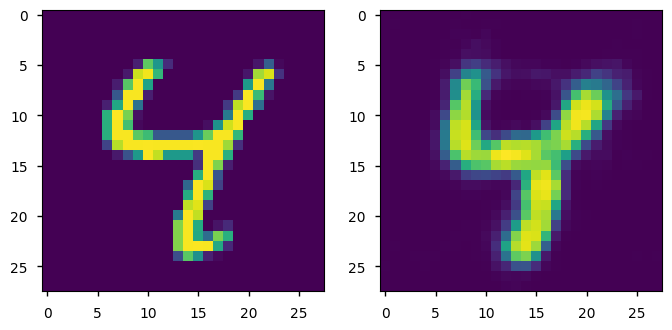

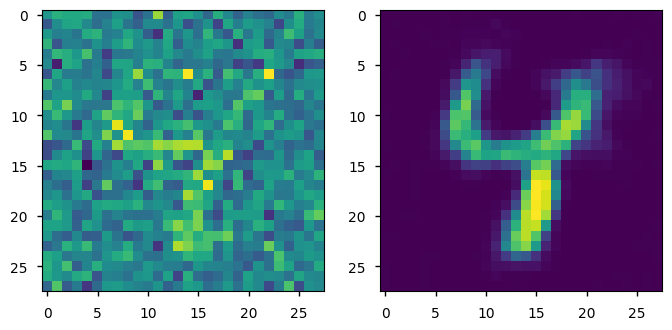

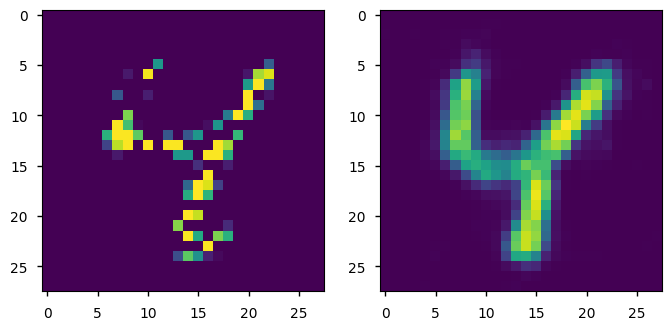

In [34]:
show_encode_decode(dnauto_encode_decode_dropout, test_data_xy[6][0])  #Clean data
show_encode_decode(dnauto_encode_decode_dropout, add_noise(test_data_xy[6][0]))  #guassian noise
show_encode_decode(dnauto_encode_decode_dropout, nn.Dropout()(test_data_xy[6][0]))  #dropout noise